# **Momentum Alpha: Dual-momentum regime switching under Halal screens**

This study tests whether **12–1 month relative price strength** inside a Halal-screened S&P 500 universe can compound, and whether a **200-day simple moving average (SMA) regime filter** on the broad market improves entry and exit during drawdowns. After dropping banned businesses and names above the AAOIFI debt cap (`< 30%`), we rank survivors by **trailing momentum** (12 months ending 1 month ago, relative to SPY) and **own the top quintile in proportion to company size**. When SPY closes below its 200-day SMA, the book moves to cash until the trend recovers.

**What this notebook does, in plain terms:** start with US large caps, keep only Sharia-compliant names, buy the recent winners, step aside when the broad market trend turns down, then measure whether that beat the market and how much it costs to run.


## Setup

Install dependencies and configure the backtest window.

`FAST_MODE = False` uses the full S&P 500 (slower: SEC / yfinance calls). Keep it `True` only for a smoke test. Performance stats start on the first day the strategy actually holds stocks, not on `START`.

Momentum needs price history before `START`: we download an extra warmup window for the 12–1 lookback and the 200-day SMA.

**What the code cell does:**
- Installs `halalquant`, `yfinance`, and plotting libraries.
- Sets the backtest dates (`START`, `END`) and strategy knobs: momentum lookback, SMA length, how many top stocks to keep, rebalance frequency, and trading-cost assumptions.
- `FAST_MODE` shrinks the universe for a quick test; `MIN_HOLDINGS` is the minimum names needed before we invest that month.

**SEC fundamentals:** AAOIFI screens need SEC EDGAR history. The setup cell installs the local `halalquant` repo (`Development/halalquant`) when present, otherwise PyPI. Set `HALALQUANT_SEC_UA` to your name and email if SEC requests fail. **Restart the kernel** after the first setup run so imports pick up the updated package.



In [1]:
import os
import subprocess
import sys
from datetime import date
from io import StringIO
from pathlib import Path

import requests
from IPython.display import display


def resolve_notebook_dir() -> Path:
    """Jupyter sometimes loses cwd(); find this notebook's folder reliably."""
    candidates = [Path.cwd()]
    candidates.append(
        Path.home() / "Documents/Development/Monterey-Finance/Research/papers/04-dual-momentum-reg-switch"
    )
    for path in candidates:
        try:
            resolved = path.resolve()
        except OSError:
            continue
        if resolved.is_dir() and (resolved / "code.ipynb").exists():
            return resolved
    return Path.cwd()


NB_DIR = resolve_notebook_dir()
os.chdir(NB_DIR)

HQ_ROOT = NB_DIR.parents[3] / "halalquant"
PIP_DEPS = ["yfinance", "matplotlib", "requests"]

if HQ_ROOT.is_dir() and (HQ_ROOT / "pyproject.toml").exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", str(HQ_ROOT)],
        cwd=str(NB_DIR),
        check=False,
    )
    hq_src = str(HQ_ROOT)
    if hq_src not in sys.path:
        sys.path.insert(0, hq_src)
else:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "halalquant"] + PIP_DEPS,
        cwd=str(NB_DIR),
        check=False,
    )

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q"] + PIP_DEPS,
    cwd=str(NB_DIR),
    check=False,
)

os.environ.setdefault(
    "HALALQUANT_SEC_UA",
    "Monterey Finance Research halalquant/0.1.0 research@montereyfinance.com",
)

import warnings

import halalquant as hq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from halalquant.providers._yfinance import YFinanceProvider, _map_yahoo_activity, _ticker_info
from halalquant.screening._aaoifi import AAOIFIScreener
from halalquant.screening._sector_filter import SectorFilter

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Backtest configuration ---
START = "2019-01-01"
END = "2024-12-31"
WARMUP_MONTHS = 15           # extra history for 12-1 momentum + 200-day SMA
MOM_LOOKBACK = 252           # ~12 months of trading days
MOM_SKIP = 21                # skip the most recent ~1 month (12-1 convention)
SMA_WINDOW = 200             # absolute trend filter on the market proxy
REGIME_TICKER = "SPY"        # broad-market regime signal
KEEP_QUANTILE = 0.20         # top quintile by relative momentum
REBALANCE_FREQ = "ME"
DEBT_THRESHOLD = 0.30
FAST_MODE = True            # True → 60 names (smoke test); False → full S&P 500
MIN_HOLDINGS = 5 if FAST_MODE else 15
RISK_FREE_RATE = 0.02
COST_BPS = 10
STRATEGY_LABEL = "Halal dual momentum"
ROBUST_LABEL = "Momentum (no SMA filter)"

BENCHMARKS = {
    "S&P 500": "SPY",
    "Halal (SPUS)": "SPUS",
}

print(f"notebook dir: {NB_DIR}")
print(f"halalquant v{hq.__version__} from {Path(hq.__file__).resolve().parent.parent}")
print(f"FAST_MODE={FAST_MODE}  MIN_HOLDINGS={MIN_HOLDINGS}")




[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


notebook dir: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/04-dual-momentum-reg-switch
halalquant v0.1.0 from /Users/raoabdul/Documents/Development/halalquant
FAST_MODE=True  MIN_HOLDINGS=5


## Step 1 — Start with a universe of stocks

We use **S&P 500 constituents** as the broad US equity universe, then pre-filter excluded business activities (banks, alcohol, gambling, etc.) using `halalquant`'s sector screen. GICS labels are stored for later sector-mix attribution.

**What the code cell does:**
- `load_sp500_tickers()` — downloads the current S&P 500 symbol list (Wikipedia, with a small offline fallback).
- `apply_sector_screen()` — loops through each ticker, maps its Yahoo sector/industry to a Halal activity label, drops banned businesses, and saves GICS tags for later charts.
- Prints how many names survive the first screen.


In [2]:
FALLBACK_SP500 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "LLY", "AVGO", "JPM",
    "UNH", "XOM", "V", "MA", "PG", "COST", "HD", "JNJ", "ABBV", "NFLX",
    "CRM", "MRK", "AMD", "PEP", "KO", "TMO", "ADBE", "WMT", "CSCO", "ACN",
    "MCD", "LIN", "ABT", "DHR", "INTC", "CMCSA", "TXN", "QCOM", "INTU", "AMAT",
    "DIS", "IBM", "GE", "CAT", "NOW", "VZ", "AMGN", "PFE", "ISRG", "GS",
]


def load_sp500_tickers() -> list[str]:
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "MontereyFinanceResearch/1.0 (halal-quant-notebook)"}
    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        table = pd.read_html(StringIO(response.text), attrs={"id": "constituents"})[0]
        return table["Symbol"].astype(str).str.replace(".", "-", regex=False).tolist()
    except Exception as exc:
        print(f"Could not fetch S&P 500 list ({exc}); using fallback basket.")
        return FALLBACK_SP500.copy()


def apply_sector_screen(tickers: list[str]) -> tuple[list[str], pd.DataFrame, dict[str, str], pd.DataFrame]:
    sector_map: dict[str, str] = {}
    gics_rows: list[dict] = []
    n = len(tickers)
    for i, symbol in enumerate(tickers, 1):
        if i == 1 or i % 50 == 0 or i == n:
            print(f"  Sector / GICS labels {i}/{n}", flush=True)
        info = _ticker_info(yf.Ticker(symbol))
        y_sector = str(info.get("sector") or "")
        y_industry = str(info.get("industry") or "")
        mapped = _map_yahoo_activity(y_sector, y_industry)
        if mapped:
            sector_map[symbol] = mapped
        gics_rows.append(
            {
                "symbol": symbol,
                "gics_sector": y_sector or "Unclassified",
                "gics_industry": y_industry or "Unclassified",
            }
        )

    sector_filter = SectorFilter()
    kept = sector_filter.filter_symbols(tickers, sector_map=sector_map)
    audit = pd.DataFrame(sector_filter.audit_log)
    gics = pd.DataFrame(gics_rows).set_index("symbol")
    return kept, audit, sector_map, gics


raw_universe = load_sp500_tickers()
if FAST_MODE:
    raw_universe = raw_universe[:60]
    print("FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.\n")

eligible_universe, sector_audit, activity_labels, gics = apply_sector_screen(raw_universe)

print(f"Raw universe:      {len(raw_universe)} tickers")
print(f"After sector screen: {len(eligible_universe)} tickers")
print(f"Removed by sector:   {len(raw_universe) - len(eligible_universe)}")

sector_audit.head(10)


FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.

  Sector / GICS labels 1/60
  Sector / GICS labels 50/60
  Sector / GICS labels 60/60
Raw universe:      60 tickers
After sector screen: 49 tickers
Removed by sector:   11


,symbol,sector,reason
0,AFL,conventional insurance,excluded business activity
1,ALL,conventional insurance,excluded business activity
2,MO,tobacco,excluded business activity
3,AXP,conventional banking,excluded business activity
4,AIG,conventional insurance,excluded business activity
5,AON,conventional insurance,excluded business activity
6,ACGL,conventional insurance,excluded business activity
7,AJG,conventional insurance,excluded business activity
8,AIZ,conventional insurance,excluded business activity
9,AXON,defense,excluded business activity


## Steps 2–6 — Filter, score, select, rebalance

Pipeline at each rebalance date (point-in-time, no look-ahead):

1. **FILTER** — AAOIFI screens, including debt / 24-month market cap `< 30%`
2. **SCORE** — 12–1 momentum: `P(t−1m) / P(t−12m) − 1`, minus the same window for SPY (relative strength)
3. **SELECT** — keep the top quintile (`KEEP_QUANTILE = 0.20`) of the Halal pool by relative momentum
4. **REGIME** — if SPY closes below its 200-day SMA, hold cash until the trend recovers (checked daily between rebalances)
5. **WEIGHT** — cap-weight among selected names
6. **REBALANCE** — monthly (`REBALANCE_FREQ = "ME"`)

Need at least `MIN_HOLDINGS` names or that month is skipped. Performance starts on the first invested day.

A robustness sleeve runs the **same momentum screen without the SMA regime filter** to isolate drawdown protection from the trend overlay.

**What the first code cell does (helper functions):**
- `trailing_return()` — measures how much a stock rose over the last 12 months, skipping the most recent month.
- `regime_risk_on()` — returns `True` when SPY is above its 200-day average (risk-on), else `False`.
- `assign_cap_weights()` — gives bigger companies a larger slice of the portfolio.
- `select_momentum()` — on one rebalance date: Halal filter → score momentum → keep the top quintile → cap-weight.
- `run_momentum_backtest()` — walks through every month and every trading day, building daily portfolio returns (with or without the SMA cash rule).
- `calc_performance_stats()` — turns daily returns into CAGR, volatility, Sharpe, drawdown, etc.


In [3]:
def price_on_or_before(price_panel: pd.DataFrame, symbol: str, as_of) -> float:
    if symbol not in price_panel.columns:
        return np.nan
    s = price_panel[symbol].dropna()
    s = s.loc[:pd.Timestamp(as_of)]
    return float(s.iloc[-1]) if not s.empty else np.nan


def trailing_return(price_panel: pd.DataFrame, symbol: str, as_of, lookback: int, skip: int) -> float:
    if symbol not in price_panel.columns:
        return np.nan
    s = price_panel[symbol].dropna()
    s = s.loc[:pd.Timestamp(as_of)]
    if len(s) < lookback + skip + 1:
        return np.nan
    end_px = float(s.iloc[-1 - skip])
    start_px = float(s.iloc[-1 - skip - lookback])
    if start_px <= 0:
        return np.nan
    return end_px / start_px - 1.0


def regime_risk_on(spy_series: pd.Series, as_of, sma_window: int = SMA_WINDOW) -> bool:
    s = spy_series.dropna().loc[:pd.Timestamp(as_of)]
    if len(s) < sma_window:
        return False
    px = float(s.iloc[-1])
    sma = float(s.iloc[-sma_window:].mean())
    return px > sma


def assign_cap_weights(selected: pd.DataFrame) -> pd.DataFrame:
    out = selected.copy()
    if out.empty:
        out["weight"] = pd.Series(dtype=float)
        return out
    cap = pd.to_numeric(out["market_cap"], errors="coerce").clip(lower=0)
    total = float(cap.sum(skipna=True))
    if np.isfinite(total) and total > 0:
        out["weight"] = cap / total
        out["weight"] = out["weight"].fillna(0.0)
        wsum = float(out["weight"].sum())
        out["weight"] = out["weight"] / wsum if wsum > 0 else 1.0 / len(out)
    else:
        out["weight"] = 1.0 / len(out)
    return out


def select_momentum(
    panel: pd.DataFrame,
    price_panel: pd.DataFrame,
    spy_series: pd.Series,
    as_of: date,
    keep_quantile: float = KEEP_QUANTILE,
    min_holdings: int = MIN_HOLDINGS,
    screener: AAOIFIScreener | None = None,
) -> pd.DataFrame:
  empty_cols = [
      "symbol", "mom_12_1", "rel_mom", "market_cap", "weight",
      "debt_ratio", "cash_ratio", "receivables_ratio",
  ]
  screener = screener or AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
  as_of_d = pd.Timestamp(as_of).date()
  snap = panel[pd.to_datetime(panel["as_of"]).dt.date == as_of_d].copy()
  if snap.empty:
      return pd.DataFrame(columns=empty_cols)

  screened = screener.evaluate_compliance(snap)
  snap = snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio") if c in snap.columns])
  passed = snap.merge(screened, on="symbol", how="inner")
  passed = passed[passed["is_compliant"].fillna(False)].copy()
  passed = passed[pd.to_numeric(passed["market_cap"], errors="coerce") > 0]

  spy_mom = trailing_return(price_panel, REGIME_TICKER, as_of, MOM_LOOKBACK, MOM_SKIP)
  rows = []
  for _, r in passed.iterrows():
      sym = r["symbol"]
      mom = trailing_return(price_panel, sym, as_of, MOM_LOOKBACK, MOM_SKIP)
      if pd.isna(mom) or not np.isfinite(mom):
          continue
      rel = mom - spy_mom if pd.notna(spy_mom) else mom
      rows.append({**r.to_dict(), "mom_12_1": mom, "rel_mom": rel})

  if not rows:
      return pd.DataFrame(columns=empty_cols)

  scored = pd.DataFrame(rows)
  effective_min = min(min_holdings, max(5, len(scored)))
  if len(scored) < 5:
      return pd.DataFrame(columns=empty_cols)

  cutoff = scored["rel_mom"].quantile(1.0 - keep_quantile)
  selected = scored[scored["rel_mom"] >= cutoff].copy()
  if len(selected) < effective_min:
      selected = scored.nlargest(effective_min, "rel_mom").copy()

  selected = assign_cap_weights(selected)
  keep = [c for c in empty_cols if c in selected.columns]
  return selected[keep].sort_values("weight", ascending=False)


def run_momentum_backtest(
    metrics: pd.DataFrame,
    prices: pd.DataFrame,
    use_regime_filter: bool = True,
    keep_quantile: float = KEEP_QUANTILE,
    min_holdings: int = MIN_HOLDINGS,
) -> tuple[pd.DataFrame, pd.DataFrame, list[date], pd.Series]:
    screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)

    price_panel = (
        prices.pivot(index="date", columns="symbol", values="adj_close")
        .sort_index()
        .ffill()
    )
    price_panel.index = pd.to_datetime(price_panel.index)
    daily_returns = price_panel.pct_change(fill_method=None)

    spy_px = price_panel[REGIME_TICKER].dropna() if REGIME_TICKER in price_panel.columns else pd.Series(dtype=float)

    rebalance_dates = sorted(pd.to_datetime(metrics["as_of"].dropna().unique()).date)
    weights_by_date: dict[date, pd.Series] = {}
    selection_log: list[pd.DataFrame] = []
    regime_log: list[dict] = []

    for as_of in rebalance_dates:
        picks = select_momentum(
            metrics,
            price_panel,
            spy_px,
            as_of=as_of,
            keep_quantile=keep_quantile,
            min_holdings=min_holdings,
            screener=screener,
        )
        risk_on = regime_risk_on(spy_px, as_of)
        regime_log.append({"as_of": as_of, "risk_on": risk_on})
        if picks.empty:
            weights_by_date[as_of] = pd.Series(dtype=float)
        else:
            weights_by_date[as_of] = picks.set_index("symbol")["weight"].astype(float)
            selection_log.append(picks.assign(as_of=as_of, risk_on=risk_on))

    selection_df = (
        pd.concat(selection_log, ignore_index=True)
        if selection_log
        else pd.DataFrame(columns=["symbol", "mom_12_1", "rel_mom", "weight", "as_of"])
    )
    regime_df = pd.DataFrame(regime_log)

    port_rows: list[dict] = []
    active_w = pd.Series(dtype=float)
    last_rebalance: date | None = None
    live = False

    for dt in daily_returns.index:
        if dt.date() < pd.Timestamp(START).date():
            continue

        prior = [d for d in rebalance_dates if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last_rebalance:
            active_w = weights_by_date.get(prior[-1], pd.Series(dtype=float))
            last_rebalance = prior[-1]
            if not active_w.empty:
                live = True

        if not live:
            port_rows.append({"date": dt.date(), "return": np.nan, "in_market": False})
            continue

        in_market = True
        if use_regime_filter and not regime_risk_on(spy_px, dt):
            in_market = False

        if not in_market or active_w.empty:
            port_rows.append({"date": dt.date(), "return": 0.0, "in_market": in_market})
            continue

        held = [s for s in active_w.index if s in daily_returns.columns]
        w = active_w.reindex(held).astype(float)
        w = w[w > 0]
        if w.empty:
            port_rows.append({"date": dt.date(), "return": 0.0, "in_market": in_market})
            continue
        w = w / w.sum()
        day_ret = (daily_returns.loc[dt, w.index] * w).sum(skipna=True)
        port_rows.append({
            "date": dt.date(),
            "return": 0.0 if pd.isna(day_ret) else float(day_ret),
            "in_market": True,
        })

    port_returns = pd.DataFrame(port_rows)
    port_returns["date"] = pd.to_datetime(port_returns["date"])
    return port_returns, selection_df, rebalance_dates, regime_df


def calc_performance_stats(daily_returns: pd.Series, label: str, rf: float = RISK_FREE_RATE) -> dict:
    r = daily_returns.dropna()
    if r.empty:
        return {
            "Strategy": label, "CAGR": np.nan, "Volatility": np.nan, "Sharpe": np.nan,
            "Sortino": np.nan, "Max Drawdown": np.nan, "Calmar": np.nan,
        }
    equity = (1 + r).cumprod()
    years = len(r) / 252
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std() * np.sqrt(252)
    excess = r - rf / 252
    sharpe = excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else np.nan
    downside = r[r < 0]
    sortino = (r.mean() - rf / 252) / downside.std() * np.sqrt(252) if len(downside) else np.nan
    dd = equity / equity.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return {
        "Strategy": label,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }


### Download prices and fundamentals

**What this code cell does:**
- Pulls point-in-time AAOIFI financial snapshots for every rebalance month (`hq.get_financial_metrics`).
- Downloads adjusted prices for all eligible stocks plus SPY/SPUS, starting earlier than `START` so momentum and the 200-day SMA have enough history.
- Shows a preview of the metrics table.


In [4]:
price_start = (pd.Timestamp(START) - pd.DateOffset(months=WARMUP_MONTHS)).strftime("%Y-%m-%d")

print("Fetching point-in-time AAOIFI metrics …")
metrics = hq.get_financial_metrics(
    eligible_universe,
    start=START,
    end=END,
    freq=REBALANCE_FREQ,
)
print(f"  {metrics.shape[0]} snapshot rows")

all_symbols = sorted(set(eligible_universe) | set(BENCHMARKS.values()) | {REGIME_TICKER})
print(f"Downloading price history from {price_start} …")
prices = hq.download(all_symbols, start=price_start, end=END)
prices["date"] = pd.to_datetime(prices["date"])
print(f"  {prices['symbol'].nunique()} symbols, {prices['date'].nunique()} trading days")

metrics.head()


Fetching point-in-time AAOIFI metrics …
  3345 snapshot rows
  51 symbols, 1823 trading days


,symbol,as_of,report_date,filed_date,total_debt,cash_and_equiv,interest_bearing_securities,receivables,liquid_assets,market_cap,market_cap_24m,debt_ratio,cash_ratio,receivables_ratio,total_revenue,non_compliant_income,impure_ratio
0,AVY,2019-01-31,2017-12-30,2018-02-21,1.581700e+09,2.244000e+08,0.000000e+00,1.180300e+09,2.244000e+08,9.192805e+09,8.726807e+09,0.181246,0.025714,0.160964,6613800000.0,NaN,NaN
1,AMD,2019-01-31,2017-12-30,2018-02-27,1.325000e+09,1.185000e+09,0.000000e+00,4.000000e+08,1.185000e+09,2.360447e+10,1.469800e+10,0.090148,0.080623,0.107838,5329000000.0,NaN,NaN
2,ARE,2019-01-31,2017-12-31,2018-01-30,4.764807e+09,2.543810e+08,1.095110e+08,1.026200e+07,3.638920e+08,1.314251e+10,1.217156e+10,0.391471,0.029897,0.030740,NaN,6680000.0,NaN
3,AMZN,2019-01-31,2017-12-31,2018-02-02,2.474300e+10,2.052200e+10,1.046400e+10,1.316400e+10,3.098600e+10,4.159327e+10,3.237217e+10,0.764329,0.957180,1.363826,177866000000.0,202000000.0,0.001136
4,APTV,2019-01-31,2017-12-31,2018-02-05,4.149000e+09,1.596000e+09,0.000000e+00,2.440000e+09,1.596000e+09,2.103590e+10,2.148543e+10,0.193108,0.074283,0.187848,NaN,7000000.0,NaN


### Run the backtest

**What this code cell does:**
- Sanity-checks the last rebalance: how many names pass Halal screens vs how many momentum picks we actually buy, and whether SPY is risk-on or risk-off.
- Runs the main strategy (momentum + SMA cash rule) and a robustness version (momentum only, no SMA filter).
- Prints the first/last invested dates, typical holdings count, and the latest portfolio.


In [5]:
# Funnel on the last rebalance date
_as_of = sorted(pd.to_datetime(metrics["as_of"].dropna().unique()).date)[-1]
_price_panel = prices.pivot(index="date", columns="symbol", values="adj_close").sort_index().ffill()
_spy = _price_panel[REGIME_TICKER].dropna() if REGIME_TICKER in _price_panel.columns else pd.Series(dtype=float)
_screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
_snap = metrics[pd.to_datetime(metrics["as_of"]).dt.date == _as_of]
_halal = _snap.merge(_screener.evaluate_compliance(_snap), on="symbol", how="inner")
_halal = _halal[_halal["is_compliant"].fillna(False)]
_scored = select_momentum(metrics, _price_panel, _spy, _as_of)
print(
    f"Funnel on {_as_of}: fundamentals={len(_snap)}  Halal={len(_halal)}  "
    f"momentum picks={len(_scored)}  MIN_HOLDINGS={MIN_HOLDINGS}"
)
print(f"SPY regime on {_as_of}: {'risk-on (above 200 SMA)' if regime_risk_on(_spy, _as_of) else 'risk-off (below 200 SMA)'}")

strategy_returns, selections, rebalance_dates, regime_log = run_momentum_backtest(
    metrics=metrics,
    prices=prices[prices["symbol"].isin(eligible_universe) | (prices["symbol"] == REGIME_TICKER)],
    use_regime_filter=True,
)

robust_returns, robust_selections, _, _ = run_momentum_backtest(
    metrics=metrics,
    prices=prices[prices["symbol"].isin(eligible_universe) | (prices["symbol"] == REGIME_TICKER)],
    use_regime_filter=False,
)

live_dates = strategy_returns.loc[strategy_returns["return"].notna(), "date"]
holdings_per_date = selections.groupby("as_of")["symbol"].nunique() if not selections.empty else pd.Series(dtype=int)
in_market_pct = strategy_returns.loc[strategy_returns["return"].notna(), "in_market"].mean()

print(f"Rebalance dates with data: {len(rebalance_dates)}")
print(f"First invested date:       {live_dates.min().date() if not live_dates.empty else 'n/a'}")
print(f"Last rebalance:            {rebalance_dates[-1] if rebalance_dates else 'n/a'}")
if not holdings_per_date.empty:
    print(
        "Holdings per live rebalance: "
        f"min={int(holdings_per_date.min())}  "
        f"median={holdings_per_date.median():.0f}  "
        f"max={int(holdings_per_date.max())}"
    )
print(f"Days invested (risk-on):   {in_market_pct:.1%} of live window")

print(f"\nLatest holdings ({rebalance_dates[-1] if rebalance_dates else 'n/a'}) — largest weights first:")
if rebalance_dates and not selections.empty:
    latest = selections[selections["as_of"] == rebalance_dates[-1]].copy()
    show = latest.copy()
    for col in ("mom_12_1", "rel_mom", "weight", "debt_ratio"):
        if col in show.columns:
            show[col] = show[col].map(lambda x: f"{x:.2%}" if pd.notna(x) else "—")
    display(show.reset_index(drop=True))
else:
    print("  (no compliant picks on last rebalance date)")


Funnel on 2024-12-31: fundamentals=49  Halal=33  momentum picks=7  MIN_HOLDINGS=5
SPY regime on 2024-12-31: risk-on (above 200 SMA)
Rebalance dates with data: 72
First invested date:       2019-01-31
Last rebalance:            2024-12-31
Holdings per live rebalance: min=5  median=6  max=7
Days invested (risk-on):   80.8% of live window

Latest holdings (2024-12-31) — largest weights first:


,symbol,mom_12_1,rel_mom,market_cap,weight,debt_ratio,cash_ratio,receivables_ratio,as_of,risk_on
0,AMZN,39.93%,6.52%,2.277926e+12,85.86%,3.67%,0.054582,0.087447,2024-12-31,True
1,APP,755.62%,722.21%,1.100655e+11,4.15%,12.48%,0.020075,0.058205,2024-12-31,True
2,MMM,66.42%,33.01%,7.133270e+10,2.69%,29.73%,0.111338,0.199392,2024-12-31,True
3,ADSK,40.16%,6.74%,6.325198e+10,2.38%,4.63%,0.045182,0.062804,2024-12-31,True
4,ARES,63.70%,30.29%,5.445187e+10,2.05%,0.00%,0.009457,0.009457,2024-12-31,True
5,APH,63.18%,29.77%,4.159360e+10,1.57%,13.90%,0.053217,0.137149,2024-12-31,True
6,ANET,85.17%,51.76%,3.451244e+10,1.30%,0.00%,0.254546,0.306674,2024-12-31,True


## Step 7 — Measure performance vs benchmarks

**What the code cell does:**
- `benchmark_returns()` — gets daily returns for SPY and SPUS over the live window.
- `align_to_live()` — lines up strategy and benchmark returns on the same calendar days (only when the strategy is actually invested).
- Builds the performance table (CAGR, Sharpe, max drawdown, etc.) for the main strategy, the no-SMA robustness sleeve, and both benchmarks.
- Plots growth of $1 and rolling 12-month excess return vs the S&P 500; saves figures to `figures/`.


Live window (dual momentum): 2019-12-19 → 2024-12-30  (1265 trading days)


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Strategy,,,,,,
Halal dual momentum,20.41%,22.42%,0.85,1.10,-18.76%,1.09
Momentum (no SMA filter),11.70%,30.61%,0.45,0.60,-39.84%,0.29
S&P 500,14.75%,20.94%,0.67,0.81,-33.72%,0.44
Halal (SPUS),17.78%,21.58%,0.77,1.02,-30.80%,0.58


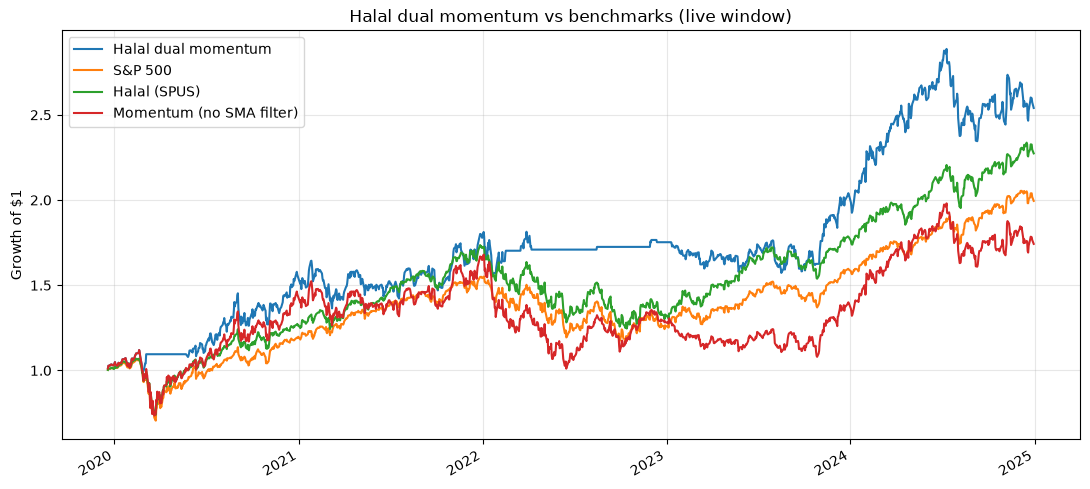

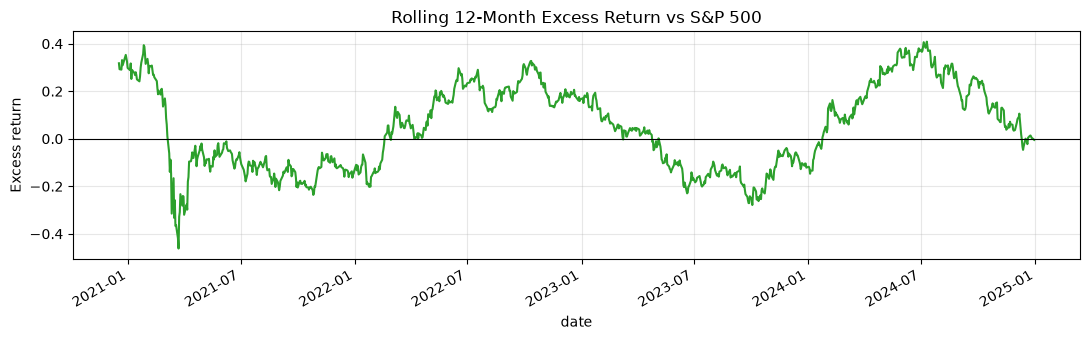

In [6]:
def benchmark_returns(ticker: str) -> pd.Series:
    px = prices[prices["symbol"] == ticker].copy()
    px["date"] = pd.to_datetime(px["date"])
    px = px.sort_values("date").set_index("date")["adj_close"]
    s = px.pct_change(fill_method=None)
    return s.loc[s.index >= pd.Timestamp(START)]


def align_to_live(strategy: pd.Series, benches: dict[str, pd.Series]) -> pd.DataFrame:
    strategy = strategy.copy()
    strategy.index = pd.to_datetime(strategy.index)
    panel = pd.DataFrame({"strategy": strategy})
    for name, series in benches.items():
        s = series.copy()
        s.index = pd.to_datetime(s.index)
        panel[name] = s
    return panel.dropna(how="any")


fig_dir = Path.cwd() / "figures"
if not (Path.cwd() / "code.ipynb").exists():
    fig_dir = Path.cwd() / "Research" / "papers" / "04-dual-momentum-reg-switch" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

bench_series = {name: benchmark_returns(ticker) for name, ticker in BENCHMARKS.items()}
strategy_s = strategy_returns.set_index("date")["return"].rename(STRATEGY_LABEL)
strategy_s.index = pd.to_datetime(strategy_s.index)
robust_s = robust_returns.set_index("date")["return"].rename(ROBUST_LABEL)
robust_s.index = pd.to_datetime(robust_s.index)

main_panel = align_to_live(strategy_s, bench_series).rename(columns={"strategy": STRATEGY_LABEL})
robust_panel = align_to_live(robust_s, bench_series).rename(columns={"strategy": ROBUST_LABEL})

if main_panel.empty:
    raise RuntimeError("No overlapping live days between the strategy and benchmarks.")

print(
    "Live window (dual momentum): "
    f"{main_panel.index.min().date()} → {main_panel.index.max().date()}  "
    f"({len(main_panel)} trading days)"
)

rows = [calc_performance_stats(main_panel[STRATEGY_LABEL], STRATEGY_LABEL)]
if not robust_panel.empty:
    rows.append(calc_performance_stats(robust_panel[ROBUST_LABEL], ROBUST_LABEL))
for name in BENCHMARKS:
    rows.append(calc_performance_stats(main_panel[name], name))

performance = pd.DataFrame(rows).set_index("Strategy")
formatters = {
    "CAGR": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Calmar": "{:.2f}",
}
display(performance.style.format(formatters))

plot_panel = main_panel.copy()
if not robust_panel.empty:
    plot_panel = plot_panel.join(robust_panel[[ROBUST_LABEL]], how="left")
equity_curves = (1 + plot_panel).cumprod()
equity_curves.plot(figsize=(11, 5), title="Halal dual momentum vs benchmarks (live window)")
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(fig_dir / "equity-curves.png", dpi=140)
plt.show()

if "S&P 500" in main_panel.columns:
    rolling_excess = (
        (1 + main_panel[STRATEGY_LABEL]).rolling(252).apply(np.prod, raw=True)
        - (1 + main_panel["S&P 500"]).rolling(252).apply(np.prod, raw=True)
    )
    rolling_excess.plot(figsize=(11, 3.5), color="tab:green", title="Rolling 12-Month Excess Return vs S&P 500")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.ylabel("Excess return")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "rolling-excess.png", dpi=140)
    plt.show()


## Step 8 — Drawdowns, calendar years, and regime exposure

**What the code cell does:**
- Plots how far the strategy fell from its prior peak (drawdowns).
- Shows calendar-year returns in a table and bar chart.
- Charts how many stocks were held at each monthly rebalance.
- Shows what share of each year the strategy was actually invested (SPY above its 200-day SMA) vs sitting in cash.


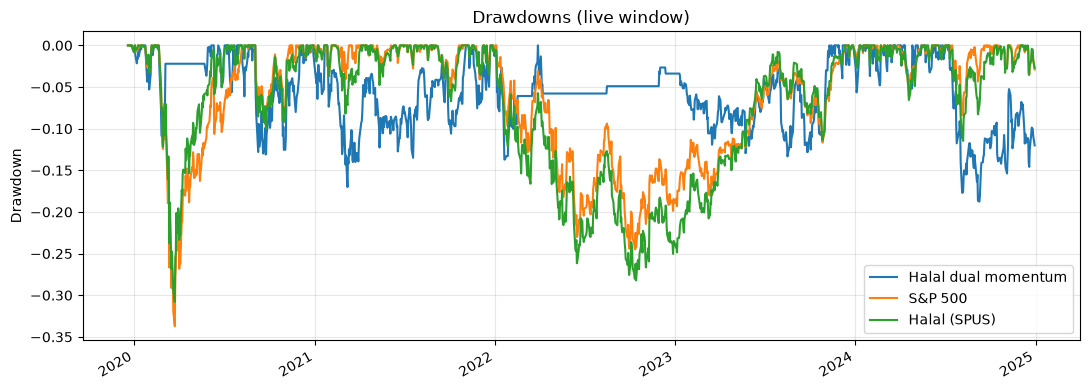

,Halal dual momentum,S&P 500,Halal (SPUS)
Year,,,
2019,3.21%,1.21%,0.81%
2020,49.43%,18.33%,25.68%
2021,15.29%,28.73%,35.62%
2022,-1.44%,-18.18%,-22.76%
2023,15.95%,26.18%,34.20%
2024,25.01%,25.34%,27.67%


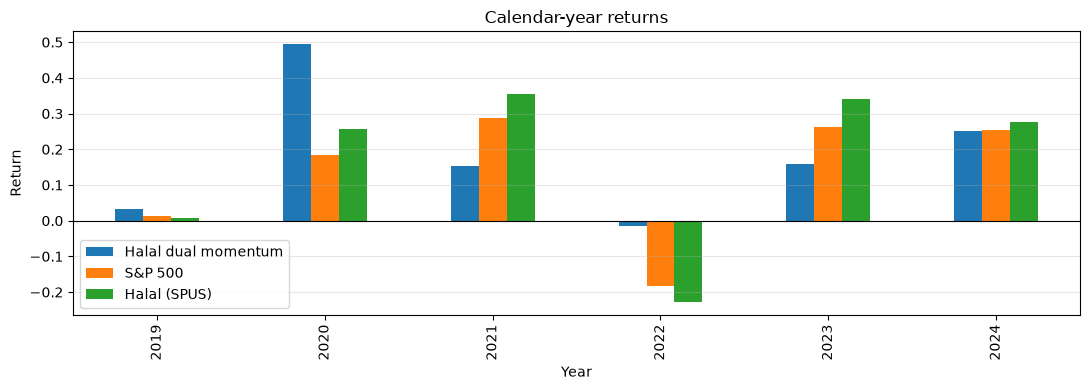

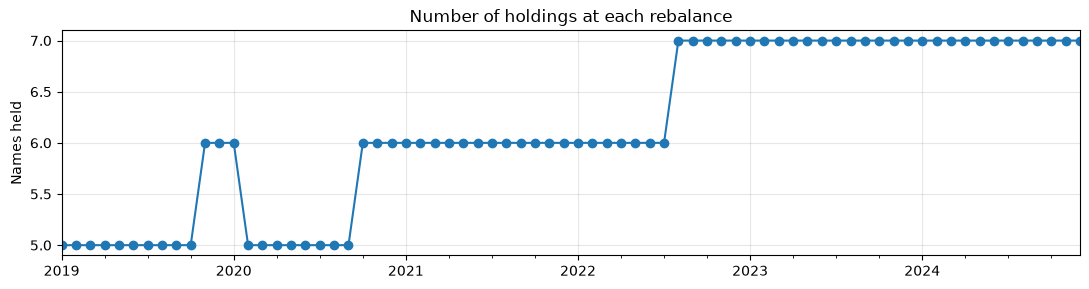

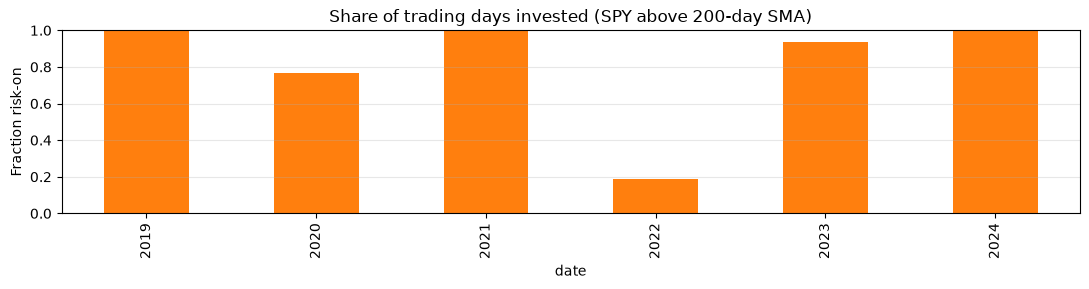

In [7]:
equity_live = (1 + main_panel).cumprod()
drawdowns = equity_live / equity_live.cummax() - 1
drawdowns.plot(figsize=(11, 4), title="Drawdowns (live window)")
plt.ylabel("Drawdown")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "drawdowns.png", dpi=140)
plt.show()

yearly = (1 + main_panel).resample("YE").prod() - 1
yearly.index = yearly.index.year
yearly.index.name = "Year"
display(yearly.style.format("{:.2%}").set_caption("Calendar-year returns (live window)"))

yearly.plot(kind="bar", figsize=(11, 4), title="Calendar-year returns")
plt.ylabel("Return")
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "calendar-year-returns.png", dpi=140)
plt.show()

if not selections.empty:
    holdings_count = selections.groupby("as_of")["symbol"].nunique().sort_index()
    holdings_count.index = pd.to_datetime(holdings_count.index)
    holdings_count.plot(figsize=(11, 3), marker="o", title="Number of holdings at each rebalance")
    plt.ylabel("Names held")
    plt.xlabel("")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "holdings-count.png", dpi=140)
    plt.show()

# Regime exposure: % of live days invested vs cash
live_regime = strategy_returns.set_index("date").loc[main_panel.index]
regime_share = live_regime.groupby(live_regime.index.year)["in_market"].mean()
regime_share.plot(kind="bar", figsize=(11, 3), color="tab:orange", title="Share of trading days invested (SPY above 200-day SMA)")
plt.ylabel("Fraction risk-on")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "regime-exposure.png", dpi=140)
plt.show()


## Step 9 — Does higher momentum actually pay?

We sort the Halal universe into quintiles by 12–1 relative momentum each month and track cap-weighted returns. A monotonic spread supports the momentum factor inside the screened pool.

**What the code cell does:**
- `halal_with_momentum()` — on each rebalance date, keeps Halal names and attaches their relative momentum score.
- Splits that list into five buckets (Q1 = highest momentum, Q5 = lowest) and cap-weights each bucket.
- `cap_weighted_returns()` — simulates daily returns for each quintile portfolio from its weight history.
- Compares quintile performance and plots the Q1 minus Q5 spread to see if winners keep winning inside the Halal pool.


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Strategy,,,,,,
Q1 (high→low momentum),14.27%,26.71%,0.56,0.72,-33.80%,0.42
Q2 (high→low momentum),20.95%,25.21%,0.80,1.11,-43.14%,0.49
Q3 (high→low momentum),27.40%,24.69%,1.02,1.36,-36.91%,0.74
Q4 (high→low momentum),10.54%,27.51%,0.43,0.58,-38.56%,0.27
Q5 (high→low momentum),16.20%,28.79%,0.60,0.79,-39.84%,0.41


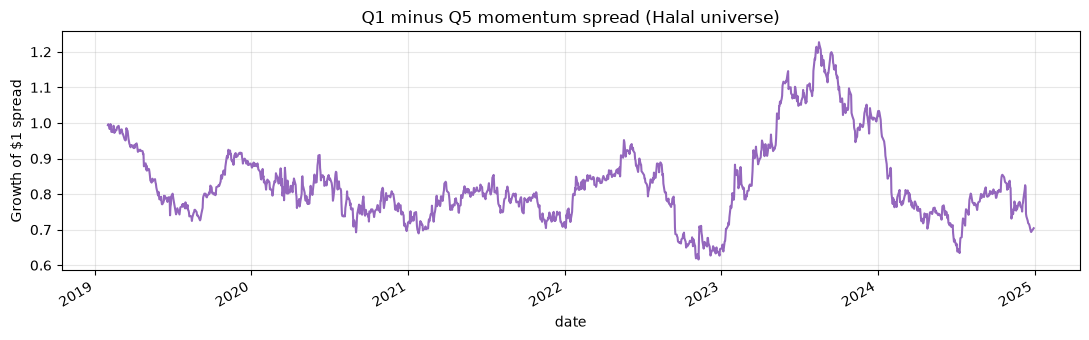

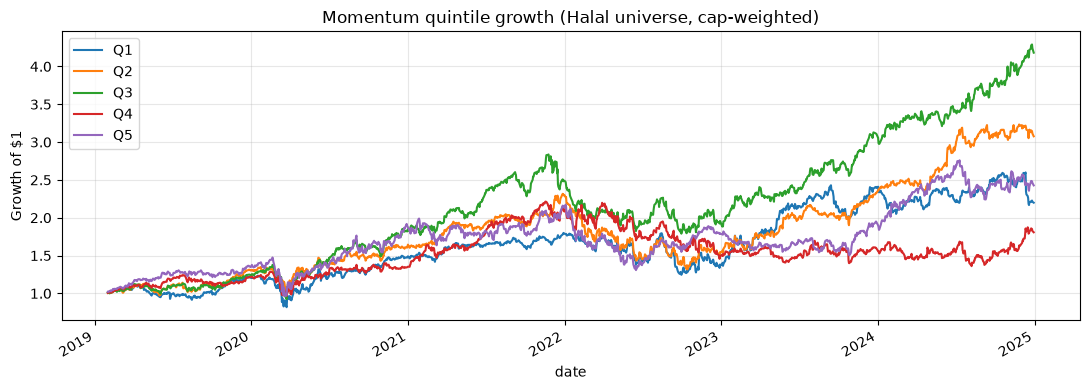

In [8]:
def cap_weighted_returns(weights_by_date: dict[date, pd.Series], daily_returns: pd.DataFrame) -> pd.Series:
    rebal = sorted(weights_by_date)
    active_w = pd.Series(dtype=float)
    last: date | None = None
    live = False
    rows: list[float] = []
    live_index = daily_returns.index[daily_returns.index >= pd.Timestamp(START)]
    for dt in live_index:
        prior = [d for d in rebal if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last:
            active_w = weights_by_date.get(prior[-1], pd.Series(dtype=float))
            last = prior[-1]
            if not active_w.empty:
                live = True
        if not live:
            rows.append(np.nan)
            continue
        held = [s for s in active_w.index if s in daily_returns.columns]
        w = active_w.reindex(held).astype(float)
        w = w[w > 0]
        if w.empty:
            rows.append(0.0)
            continue
        w = w / w.sum()
        day_ret = (daily_returns.loc[dt, w.index] * w).sum(skipna=True)
        rows.append(0.0 if pd.isna(day_ret) else float(day_ret))
    return pd.Series(rows, index=pd.to_datetime(live_index), name="return")


N_Q = 5
screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
momentum_symbols = sorted(set(eligible_universe) | {REGIME_TICKER})
price_panel = (
    prices[prices["symbol"].isin(momentum_symbols)]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
price_panel.index = pd.to_datetime(price_panel.index)
stock_returns = price_panel.pct_change(fill_method=None)
spy_series = price_panel[REGIME_TICKER].dropna()


def halal_with_momentum(as_of: date) -> pd.DataFrame:
    snap = metrics[pd.to_datetime(metrics["as_of"]).dt.date == pd.Timestamp(as_of).date()].copy()
    if snap.empty:
        return snap
    screened = screener.evaluate_compliance(snap)
    snap = snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio") if c in snap.columns])
    passed = snap.merge(screened, on="symbol", how="inner")
    passed = passed[passed["is_compliant"].fillna(False)].copy()
    passed = passed[pd.to_numeric(passed["market_cap"], errors="coerce") > 0]
    spy_mom = trailing_return(price_panel, REGIME_TICKER, as_of, MOM_LOOKBACK, MOM_SKIP)
    rows = []
    for _, r in passed.iterrows():
        mom = trailing_return(price_panel, r["symbol"], as_of, MOM_LOOKBACK, MOM_SKIP)
        if pd.isna(mom):
            continue
        rows.append({**r.to_dict(), "rel_mom": mom - spy_mom if pd.notna(spy_mom) else mom})
    return pd.DataFrame(rows) if rows else pd.DataFrame()


quantile_w: dict[int, dict[date, pd.Series]] = {q: {} for q in range(1, N_Q + 1)}
for as_of in rebalance_dates:
    ranked = halal_with_momentum(as_of)
    if ranked.empty or len(ranked) < N_Q * 3:
        continue
    ranked = ranked.sort_values("rel_mom", ascending=False)
    ranked["q"] = pd.qcut(ranked["rel_mom"], N_Q, labels=False, duplicates="drop") + 1
    for q in range(1, N_Q + 1):
        bucket = ranked[ranked["q"] == q]
        if bucket.empty:
            continue
        wdf = assign_cap_weights(bucket)
        quantile_w[q][as_of] = wdf.set_index("symbol")["weight"].astype(float)

q_returns = {}
for q in range(1, N_Q + 1):
    if quantile_w[q]:
        q_returns[q] = cap_weighted_returns(quantile_w[q], stock_returns)

if q_returns:
    q_panel = pd.DataFrame({f"Q{q}": s for q, s in q_returns.items()}).dropna(how="all")
    q_live = q_panel.dropna(how="any")
    if not q_live.empty:
        q_stats = [calc_performance_stats(q_live[f"Q{q}"], f"Q{q} (high→low momentum)") for q in sorted(q_returns)]
        display(pd.DataFrame(q_stats).set_index("Strategy").style.format(formatters))

        spread = q_live["Q1"] - q_live[f"Q{N_Q}"]
        spread_cum = (1 + spread.dropna()).cumprod()
        spread_cum.plot(figsize=(11, 3.5), color="tab:purple", title="Q1 minus Q5 momentum spread (Halal universe)")
        plt.ylabel("Growth of $1 spread")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(fig_dir / "quintile-spread.png", dpi=140)
        plt.show()

        (1 + q_live).cumprod().plot(figsize=(11, 4), title="Momentum quintile growth (Halal universe, cap-weighted)")
        plt.ylabel("Growth of $1")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(fig_dir / "quintile-growth.png", dpi=140)
        plt.show()


## Step 10 — Attribution: stock picking or sector tilt?

**What the code cell does:**
- `capm_attribution()` — estimates alpha, beta, tracking error, and information ratio vs SPY and SPUS.
- Compares average sector weights in the momentum book vs the broader Halal universe to see if outperformance might just be a tech/growth tilt.


,Alpha (ann.),Beta,R²,Tracking error,Information ratio
Benchmark,,,,,
S&P 500,12.30%,0.49,0.21,22.68%,0.23
Halal (SPUS),10.00%,0.54,0.27,21.48%,0.11


,Momentum book (avg. month),Halal universe (equal weight),Delta
Technology,54.6%,22.4%,32.1%
Real Estate,35.7%,4.1%,31.6%
Communication Services,28.1%,8.2%,19.9%
Healthcare,23.9%,14.3%,9.6%
Consumer Cyclical,18.8%,14.3%,4.5%
Basic Materials,8.6%,4.1%,4.5%
Consumer Defensive,6.1%,2.0%,4.1%
Industrials,5.0%,8.2%,-3.2%
Utilities,4.2%,12.2%,-8.0%
Financial Services,3.1%,6.1%,-3.0%


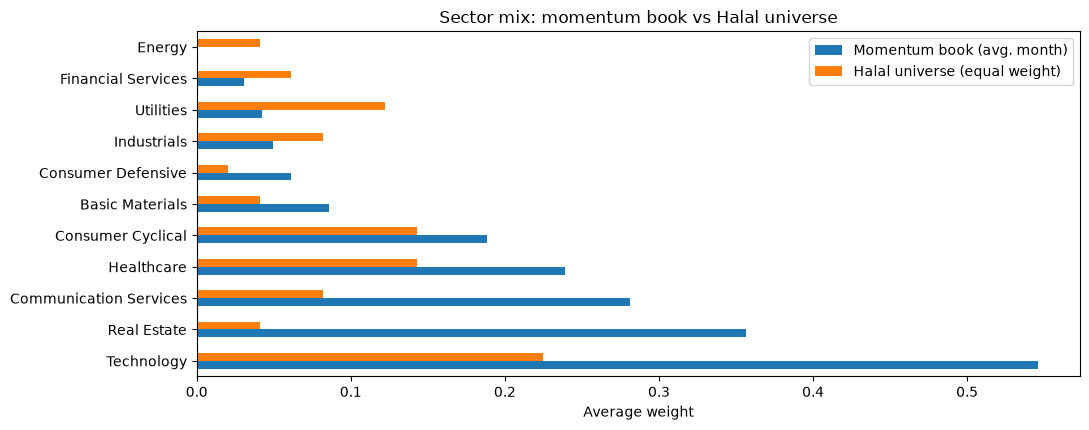

In [9]:
def capm_attribution(strategy: pd.Series, benchmark: pd.Series, rf: float = RISK_FREE_RATE) -> dict:
    aligned = pd.concat([strategy, benchmark], axis=1, keys=["y", "x"]).dropna()
    rf_d = rf / 252
    ye = aligned["y"] - rf_d
    xe = aligned["x"] - rf_d
    var_x = xe.var()
    beta = float(ye.cov(xe) / var_x) if var_x > 0 else np.nan
    alpha_d = float(ye.mean() - beta * xe.mean()) if pd.notna(beta) else np.nan
    resid = ye - alpha_d - beta * xe
    r2 = 1 - resid.var() / ye.var() if ye.var() > 0 else np.nan
    excess = aligned["y"] - aligned["x"]
    te = float(excess.std() * np.sqrt(252))
    ir = float(excess.mean() * 252 / te) if te > 0 else np.nan
    return {
        "Alpha (ann.)": alpha_d * 252,
        "Beta": beta,
        "R²": r2,
        "Tracking error": te,
        "Information ratio": ir,
    }


attr_rows = []
for bench_name in BENCHMARKS:
    row = capm_attribution(main_panel[STRATEGY_LABEL], main_panel[bench_name])
    row["Benchmark"] = bench_name
    attr_rows.append(row)
attr = pd.DataFrame(attr_rows).set_index("Benchmark")
display(attr.style.format({
    "Alpha (ann.)": "{:.2%}",
    "Beta": "{:.2f}",
    "R²": "{:.2f}",
    "Tracking error": "{:.2%}",
    "Information ratio": "{:.2f}",
}).set_caption("Halal dual momentum vs each benchmark (live window)"))

if not selections.empty:
    def average_weight_by(label_map: dict[str, str], universe_labels: pd.Series) -> pd.DataFrame:
        month_weights = []
        for as_of, snap in selections.groupby("as_of"):
            w = snap["weight"] if "weight" in snap.columns else 1 / len(snap)
            month_weights.append(
                snap.assign(weight=w)
                .assign(bucket=lambda d: d["symbol"].map(label_map).fillna("Unclassified"))
                .groupby("bucket")["weight"]
                .sum()
            )
        strat_w = pd.concat(month_weights, axis=1).mean(axis=1).rename("Momentum book (avg. month)")
        univ_w = universe_labels.value_counts(normalize=True).rename("Halal universe (equal weight)")
        mix = pd.concat([strat_w, univ_w], axis=1).fillna(0.0)
        mix["Delta"] = mix["Momentum book (avg. month)"] - mix["Halal universe (equal weight)"]
        return mix.sort_values("Momentum book (avg. month)", ascending=False)

    gics_map = gics["gics_sector"].to_dict()
    sector_mix = average_weight_by(
        gics_map,
        pd.Series({s: gics_map.get(s, "Unclassified") for s in eligible_universe}),
    )
    display(sector_mix.style.format("{:.1%}").set_caption("Average GICS sector weights · delta = strategy minus Halal universe"))
    sector_mix.drop(columns="Delta").plot(
        kind="barh",
        figsize=(11, max(4, 0.4 * len(sector_mix))),
        title="Sector mix: momentum book vs Halal universe",
    )
    plt.xlabel("Average weight")
    plt.tight_layout()
    plt.savefig(fig_dir / "sector-mix.png", dpi=140)
    plt.show()


## Step 11 — Friction: turnover, trading costs, purification

**What the code cell does:**
- `one_way_turnover()` — measures how much the portfolio changed between rebalance dates (0 = no trades, 1 = full replacement).
- Estimates annual turnover, trading-cost drag at `COST_BPS`, and CAGR net of costs.
- Calls `hq.purify_dividends()` on held names to estimate purification drag from non-permissible income while stocks were owned.


Item,Value
Rebalances with holdings,72
Average names held,6.2
Annualized one-way turnover,424.7%
Assumed cost per one-way trade,10 bps
Estimated annual trading-cost drag,0.42%
CAGR gross of trading costs,20.41%
CAGR net of trading costs,19.81%


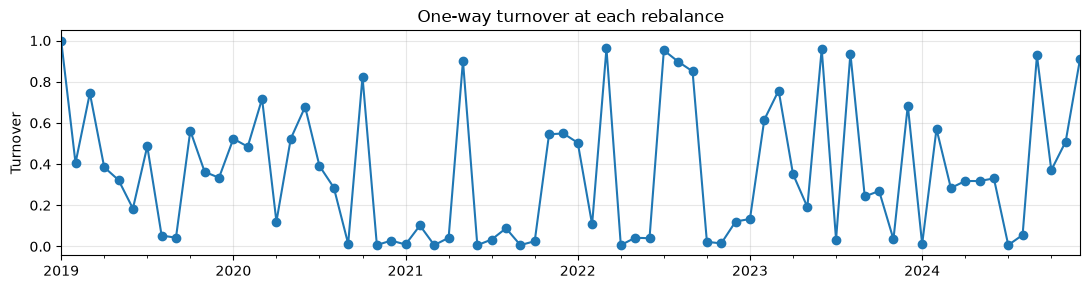

Fetching dividend purification for names the strategy held …
Dividend events while held: 31  ·  annualized purification drag ≈ 0.00%


In [10]:
def one_way_turnover(old: dict[str, float], new: dict[str, float]) -> float:
    if not new:
        return 0.0
    if not old:
        return 1.0
    names = set(old) | set(new)
    return 0.5 * sum(abs(new.get(s, 0.0) - old.get(s, 0.0)) for s in names)


if selections.empty:
    raise RuntimeError("No holdings log — re-run the backtest cell first.")

rebal_order = sorted(selections["as_of"].unique())
turnover_rows = []
prev: dict[str, float] = {}
for as_of in rebal_order:
    snap = selections.loc[selections["as_of"] == as_of]
    curr = snap.set_index("symbol")["weight"].astype(float).to_dict() if "weight" in snap.columns else {s: 1.0 / len(snap) for s in snap["symbol"]}
    turnover_rows.append({"as_of": pd.Timestamp(as_of), "one_way": one_way_turnover(prev, curr), "n": len(curr)})
    prev = curr

turnover = pd.DataFrame(turnover_rows).set_index("as_of")
months = max(len(turnover) - 1, 1)
annual_turnover = turnover["one_way"].iloc[1:].sum() * (12 / months) if len(turnover) > 1 else np.nan
cost_drag_ann = annual_turnover * COST_BPS / 10_000

cost_on_day = pd.Series(0.0, index=main_panel.index)
for as_of, row in turnover.iterrows():
    hit = main_panel.index[main_panel.index >= as_of]
    if len(hit):
        cost_on_day.loc[hit[0]] += float(row["one_way"]) * COST_BPS / 10_000

net_returns = main_panel[STRATEGY_LABEL] - cost_on_day
net_stats = calc_performance_stats(net_returns, f"{STRATEGY_LABEL} net of {COST_BPS} bps")
gross_cagr = calc_performance_stats(main_panel[STRATEGY_LABEL], STRATEGY_LABEL)["CAGR"]

friction = pd.DataFrame({
    "Item": [
        "Rebalances with holdings",
        "Average names held",
        "Annualized one-way turnover",
        "Assumed cost per one-way trade",
        "Estimated annual trading-cost drag",
        "CAGR gross of trading costs",
        "CAGR net of trading costs",
    ],
    "Value": [
        f"{len(turnover)}",
        f"{turnover['n'].mean():.1f}",
        f"{annual_turnover:.1%}",
        f"{COST_BPS} bps",
        f"{cost_drag_ann:.2%}",
        f"{gross_cagr:.2%}",
        f"{net_stats['CAGR']:.2%}",
    ],
})
display(friction.style.hide(axis="index"))

turnover["one_way"].plot(figsize=(11, 3), marker="o", title="One-way turnover at each rebalance")
plt.ylabel("Turnover")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "turnover.png", dpi=140)
plt.show()

print("Fetching dividend purification for names the strategy held …")
held_symbols = sorted(selections["symbol"].unique())
try:
    purified = hq.purify_dividends(
        held_symbols,
        start=str(main_panel.index.min().date()),
        end=END,
    )
except Exception as exc:
    purified = pd.DataFrame()
    print(f"Purification lookup failed ({exc}). Skipping drag estimate.")

if purified.empty:
    print("No purification rows returned. Report this as a data gap in the paper, not as 0% drag.")
else:
    held_flags = []
    for as_of, snap in selections.groupby("as_of"):
        held_flags.append(pd.DataFrame({"as_of": pd.Timestamp(as_of), "symbol": snap["symbol"].tolist()}))
    held_log = pd.concat(held_flags, ignore_index=True)
    purified = purified.copy()
    purified["ex_date"] = pd.to_datetime(purified["ex_date"])
    px = price_panel.copy()
    px.index = pd.to_datetime(px.index)
    drag_rows = []
    for _, div in purified.iterrows():
        symbol = div["symbol"]
        ex = div["ex_date"]
        prior_rebal = held_log.loc[held_log["as_of"] <= ex]
        if prior_rebal.empty:
            continue
        last_asof = prior_rebal["as_of"].max()
        that_book = set(held_log.loc[held_log["as_of"] == last_asof, "symbol"])
        if symbol not in that_book or symbol not in px.columns:
            continue
        hist = px.loc[:ex, symbol].dropna()
        if hist.empty or hist.iloc[-1] <= 0:
            continue
        w_snap = selections.loc[pd.to_datetime(selections["as_of"]) == last_asof]
        weight = float(w_snap.loc[w_snap["symbol"] == symbol, "weight"].iloc[0]) if symbol in set(w_snap["symbol"]) else 1 / len(that_book)
        amount = div.get("purification_amount")
        if pd.isna(amount):
            continue
        drag_rows.append(float(amount) / float(hist.iloc[-1]) * weight)
    years = len(main_panel) / 252
    purify_drag = (sum(drag_rows) / years) if years > 0 else np.nan
    print(f"Dividend events while held: {len(drag_rows)}  ·  annualized purification drag ≈ {purify_drag:.2%}")


### Notes on methodology

- **12–1 momentum** skips the most recent month to reduce short-term reversal noise; relative strength subtracts SPY's 12–1 return so the book tilts toward names outperforming the broad market.
- **200-day SMA regime** follows Gary Antonacci's absolute momentum overlay: when SPY is below its 200-day average, the strategy holds cash rather than the momentum basket. The robustness sleeve removes this filter.
- **Halal screens** are point-in-time via `halalquant` AAOIFI debt and activity rules; turnover can spike when names lose compliance.
- Performance is measured only on **live** days (after the first invested rebalance), aligned to the same calendar for benchmarks.

**In one sentence:** we only count returns from the day the strategy first holds stocks, and we never use future data when picking them.


## Summary

Quick reference for the full rule set:

| Component | Rule |
| --- | --- |
| Universe | S&P 500 → sector screen → AAOIFI |
| Signal | 12–1 month return relative to SPY |
| Selection | Top quintile by relative momentum |
| Regime | Cash when SPY < 200-day SMA |
| Weighting | Cap-weight |
| Rebalance | Monthly |
